# Chapter 58 — Causal Masking

## Learning goals

Chapter 57 constructed attention score tables with receiving query positions on rows and source key positions on columns.

This chapter enforces the left-to-right information boundary before those scores become weights.

By the end of this chapter, you should be able to:

- Explain why shifted next-token training must hide future input positions.
- State the causal rule `source_position <= receiving_position`.
- Create and label a Boolean lower-triangular mask.
- Apply that mask to a square self-attention score table.
- Explain why blocked scores become negative infinity.
- Apply softmax across allowed source positions.
- Verify that future positions receive exactly zero weight.
- Plot an annotated causal-mask heatmap.
- Explain why zeroing scores is not sufficient.
- Explain why masking after softmax breaks normalization.
- Broadcast one mask across batched score tables.

## The big idea

For causal self-attention, receiving position `i` may use source position `j` only when `j <= i`.

The allowed region is therefore on and below the score table's diagonal.

The correct operation order is:

```text
raw or scaled scores
→ replace future scores with -∞
→ softmax across source columns
→ causal attention weights
```

Negative infinity removes future positions from the softmax denominator, giving them exactly zero weight.

## Terms used in this chapter

- A **causal language model** predicts each next token using only information available up to the current position.
- A **future position** has a larger sequence index than the receiving position.
- A **causal mask** marks current and earlier source positions as allowed and future source positions as blocked.
- A **Boolean mask** stores `True` for allowed entries and `False` for blocked entries.
- A **lower-triangular matrix** contains allowed entries on and below its diagonal.
- A **masked score** is a blocked attention score replaced before softmax.
- **Negative infinity** is a value whose exponential is zero.
- **Broadcasting** applies one compatible mask across leading batch or head dimensions.

## Make the GPT rule concrete

Use the token sequence `the cat sat` and list allowed and blocked source tokens for every receiving position.

In [1]:
tokens = ["the", "cat", "sat"]

print("position | receiving token | allowed sources   | blocked future sources")
print("-" * 77)
for receiving_position, receiving_token in enumerate(tokens):
    allowed_sources = tokens[: receiving_position + 1]
    blocked_sources = tokens[receiving_position + 1 :]
    print(
        f"{receiving_position:>8} | "
        f"{receiving_token:>15} | "
        f"{str(allowed_sources):>17} | "
        f"{blocked_sources}"
    )

position | receiving token | allowed sources   | blocked future sources
-----------------------------------------------------------------------------
       0 |             the |           ['the'] | ['cat', 'sat']
       1 |             cat |    ['the', 'cat'] | ['sat']
       2 |             sat | ['the', 'cat', 'sat'] | []


When `cat` is the receiving token at position 1, it may use `the` and `cat` but not the future input token `sat`.

The current position remains allowed because the diagonal is part of ordinary GPT self-attention.

## Create a Boolean lower-triangular mask

Use `torch.tril` to keep the diagonal and everything below it.

In [2]:
import torch

device = "cpu"
context_length = len(tokens)
causal_mask = torch.tril(
    torch.ones(
        context_length,
        context_length,
        dtype=torch.bool,
        device=device,
    )
)

print("device:", device)
print("mask shape:", causal_mask.shape)
print("mask dtype:", causal_mask.dtype)
print(causal_mask)

device: cpu
mask shape: torch.Size([3, 3])
mask dtype: torch.bool
tensor([[ True, False, False],
        [ True,  True, False],
        [ True,  True,  True]])


Rows remain receiving positions, columns remain source positions, and `True` means the relationship is allowed.

## Print the mask with token labels

Make the axis contract visible in a reusable table helper.

In [3]:
def print_tensor_table(
    table: torch.Tensor,
    tokens: list[str],
    title: str,
    number_format: str,
) -> None:
    if table.ndim != 2 or table.shape != (len(tokens), len(tokens)):
        raise ValueError("table must be square and match the token count.")

    print(title)
    print("-" * len(title))
    header = "receiver \ source".rjust(18)
    for token in tokens:
        header += f" | {token:>8}"
    print(header)
    print("-" * len(header))

    for row, receiving_token in enumerate(tokens):
        row_text = f"{receiving_token:>18}"
        for column in range(len(tokens)):
            value = table[row, column].item()
            row_text += f" | {format(value, number_format):>8}"
        print(row_text)


print_tensor_table(
    causal_mask,
    tokens=tokens,
    title="Boolean causal mask",
    number_format="",
)

Boolean causal mask
-------------------
 receiver \ source |      the |      cat |      sat
---------------------------------------------------
               the |     True |    False |    False
               cat |     True |     True |    False
               sat |     True |     True |     True


The `cat` row has `False` in the `sat` column because column 2 is later than row 1.

## Plot the causal mask

Use one annotated heatmap to show the allowed lower triangle and blocked upper triangle.

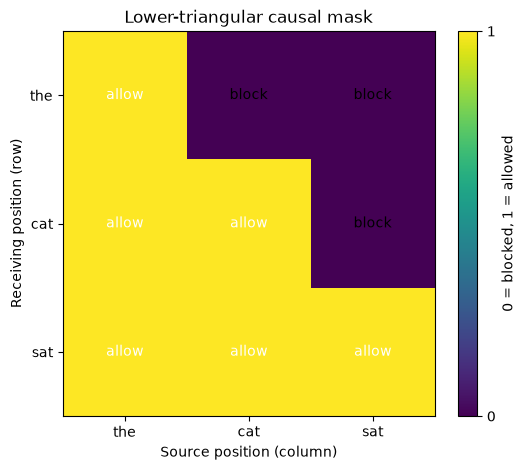

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(causal_mask, aspect="auto", vmin=0.0, vmax=1.0)
colorbar = plt.colorbar(ticks=[0, 1])
colorbar.set_label("0 = blocked, 1 = allowed")
plt.xticks(range(context_length), tokens)
plt.yticks(range(context_length), tokens)
plt.xlabel("Source position (column)")
plt.ylabel("Receiving position (row)")
plt.title("Lower-triangular causal mask")

for row in range(context_length):
    for column in range(context_length):
        label = "allow" if causal_mask[row, column] else "block"
        plt.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            color="white" if causal_mask[row, column] else "black",
        )

plt.show()

The pattern depends only on positions, so the same length-three mask works for any three-token content.

## Start from a raw score table

Choose deterministic scores whose largest entries in the first two rows point to future positions.

This makes the effect of masking impossible to miss.

In [5]:
attention_scores = torch.tensor(
    [
        [2.0, 5.0, 1.0],
        [0.5, 1.5, 4.0],
        [1.0, 2.0, 3.0],
    ],
    dtype=torch.float32,
    device=device,
)

print_tensor_table(
    attention_scores,
    tokens=tokens,
    title="Raw attention scores",
    number_format=".3f",
)

Raw attention scores
--------------------
 receiver \ source |      the |      cat |      sat
---------------------------------------------------
               the |    2.000 |    5.000 |    1.000
               cat |    0.500 |    1.500 |    4.000
               sat |    1.000 |    2.000 |    3.000


Score `[1, 2] = 4.0` is the raw compatibility of receiving token `cat` with future source token `sat`.

A causal model must remove that entry regardless of how large it is.

## Replace blocked scores with negative infinity

Use the inverse Boolean mask to select entries above the diagonal.

In [6]:
masked_attention_scores = attention_scores.masked_fill(
    ~causal_mask,
    float("-inf"),
)

print_tensor_table(
    masked_attention_scores,
    tokens=tokens,
    title="Scores after causal masking",
    number_format=".3f",
)

Scores after causal masking
---------------------------
 receiver \ source |      the |      cat |      sat
---------------------------------------------------
               the |    2.000 |     -inf |     -inf
               cat |    0.500 |    1.500 |     -inf
               sat |    1.000 |    2.000 |    3.000


Softmax exponentiates scores, and `exp(-∞) = 0`, so blocked entries contribute nothing to the numerator or denominator.

The diagonal ensures every row retains at least one finite score.

A fully masked row would instead make softmax undefined and produce `NaN` values.

## Apply softmax after masking

Normalize across the last dimension because source positions occupy the score table's columns.

In [7]:
attention_weights = torch.softmax(masked_attention_scores, dim=-1)
future_weights = attention_weights[~causal_mask]

print_tensor_table(
    attention_weights,
    tokens=tokens,
    title="Causal attention weights",
    number_format=".6f",
)
print("row sums:", attention_weights.sum(dim=-1))
print("all future weights:", future_weights)
print("every future weight is zero:", bool(torch.all(future_weights == 0)))

Causal attention weights
------------------------
 receiver \ source |      the |      cat |      sat
---------------------------------------------------
               the | 1.000000 | 0.000000 | 0.000000
               cat | 0.268941 | 0.731059 | 0.000000
               sat | 0.090031 | 0.244728 | 0.665241
row sums: tensor([1., 1., 1.])
all future weights: tensor([0., 0., 0.])
every future weight is zero: True


Every row sums to one using only its allowed positions, and all future entries are exactly zero.

The `cat` row assigns probability only to `the` and `cat`.

## Compare the exact cheating path

Without a mask, row-wise softmax assigns most of the `cat` row's weight to future token `sat`.

In [8]:
unmasked_weights = torch.softmax(attention_scores, dim=-1)
cat_position = tokens.index("cat")
sat_position = tokens.index("sat")
unmasked_cat_to_sat = unmasked_weights[cat_position, sat_position].item()
causal_cat_to_sat = attention_weights[cat_position, sat_position].item()

print("unmasked cat-to-sat weight:", unmasked_cat_to_sat)
print("causal cat-to-sat weight:", causal_cat_to_sat)
print("unmasked cat row:", unmasked_weights[cat_position])
print("causal cat row:", attention_weights[cat_position])

unmasked cat-to-sat weight: 0.8990522623062134
causal cat-to-sat weight: 0.0
unmasked cat row: tensor([0.0271, 0.0738, 0.8991])
causal cat row: tensor([0.2689, 0.7311, 0.0000])


In shifted next-token training, input positions might be `the cat sat` while their targets begin `cat sat ...`.

The target for the `cat` row is `sat`, which already appears at the next input position during parallel training.

Unmasked attention can exploit that future input as an invalid shortcut, while generation cannot because the future token has not been produced yet.

## Why setting blocked scores to zero fails

A raw score of zero remains a valid softmax input with exponential value one.

Compare zero-filled future scores with negative-infinity masking.

In [9]:
zero_filled_scores = attention_scores.masked_fill(~causal_mask, 0.0)
zero_filled_weights = torch.softmax(zero_filled_scores, dim=-1)
zero_filled_future_weights = zero_filled_weights[~causal_mask]

print("future weights after filling scores with zero:", zero_filled_future_weights)
print("future weights after filling scores with -inf:", future_weights)
print(
    "zero filling blocks future weights:",
    bool(torch.all(zero_filled_future_weights == 0)),
)

future weights after filling scores with zero: tensor([0.1065, 0.1065, 0.1402])
future weights after filling scores with -inf: tensor([0., 0., 0.])
zero filling blocks future weights: False


The zero-filled future entries still receive positive weight, so zero is not a valid blocking score.

## Why masking after softmax fails

Zeroing already-normalized future weights removes probability mass without redistributing it across allowed positions.

In [10]:
late_masked_weights = unmasked_weights.masked_fill(~causal_mask, 0.0)

print("row sums after softmax then masking:", late_masked_weights.sum(dim=-1))
print("row sums after masking then softmax:", attention_weights.sum(dim=-1))
print(
    "late-masked rows remain normalized:",
    torch.allclose(
        late_masked_weights.sum(dim=-1),
        torch.ones(context_length, device=device),
    ),
)

row sums after softmax then masking: tensor([0.0466, 0.1009, 1.0000])
row sums after masking then softmax: tensor([1., 1., 1.])
late-masked rows remain normalized: False


The first two late-masked rows sum to less than one.

Masking scores first lets softmax distribute all probability mass among allowed columns.

## Keep the diagonal

Compare ordinary causal self-attention with a strictly previous-position mask that removes self-attention.

In [11]:
strict_previous_mask = torch.tril(
    torch.ones(
        context_length,
        context_length,
        dtype=torch.bool,
        device=device,
    ),
    diagonal=-1,
)
ordinary_row_zero_is_valid = bool(causal_mask[0].any())
strict_row_zero_is_valid = bool(strict_previous_mask[0].any())

print("ordinary causal mask:")
print(causal_mask)
print("strictly previous mask:")
print(strict_previous_mask)
print("row 0 has an allowed source in ordinary mask:", ordinary_row_zero_is_valid)
print("row 0 has an allowed source in strict mask:", strict_row_zero_is_valid)

ordinary causal mask:
tensor([[ True, False, False],
        [ True,  True, False],
        [ True,  True,  True]])
strictly previous mask:
tensor([[False, False, False],
        [ True, False, False],
        [ True,  True, False]])
row 0 has an allowed source in ordinary mask: True
row 0 has an allowed source in strict mask: False


GPT self-attention normally includes the diagonal because each position may use its current token representation.

The strict mask fully blocks row zero unless a separate earlier boundary position exists.

## Package mask creation and masked softmax

Validate that attention scores are finite, floating point, nonempty, and square on their last two dimensions.

In [12]:
def make_causal_mask(
    context_length: int,
    device: torch.device | str,
) -> torch.Tensor:
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")

    return torch.tril(
        torch.ones(
            context_length,
            context_length,
            dtype=torch.bool,
            device=device,
        )
    )


def apply_causal_mask_and_softmax(
    attention_scores: torch.Tensor,
) -> dict[str, torch.Tensor]:
    if attention_scores.ndim < 2:
        raise ValueError("attention_scores must have at least two dimensions.")
    if attention_scores.shape[-2] != attention_scores.shape[-1]:
        raise ValueError("The final two score dimensions must be square.")
    if attention_scores.shape[-1] < 1:
        raise ValueError("attention_scores must contain at least one position.")
    if not torch.is_floating_point(attention_scores):
        raise ValueError("attention_scores must use a floating-point dtype.")
    if not torch.all(torch.isfinite(attention_scores)):
        raise ValueError("Unmasked attention_scores must be finite.")

    mask = make_causal_mask(
        context_length=attention_scores.shape[-1],
        device=attention_scores.device,
    )
    masked_scores = attention_scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(masked_scores, dim=-1)

    return {
        "mask": mask,
        "masked_scores": masked_scores,
        "weights": weights,
    }


causal_result = apply_causal_mask_and_softmax(attention_scores)
print("helper mask matches:", torch.equal(causal_result["mask"], causal_mask))
print(
    "helper masked scores match:",
    torch.equal(causal_result["masked_scores"], masked_attention_scores),
)
print(
    "helper weights match:",
    torch.allclose(causal_result["weights"], attention_weights),
)

helper mask matches: True
helper masked scores match: True
helper weights match: True


The helper reproduces the mask, masked scores, and weights computed step by step.

## Broadcast one mask across a batch

Stack two deterministic score tables and let the `[C, C]` mask broadcast over the leading batch dimension.

In [13]:
batched_scores = torch.stack([attention_scores, 0.5 * attention_scores])
batched_result = apply_causal_mask_and_softmax(batched_scores)
batched_weights = batched_result["weights"]
expanded_future_mask = (~batched_result["mask"]).expand_as(batched_weights)
batched_future_weights = batched_weights[expanded_future_mask]

print("batched score shape:", batched_scores.shape)
print("mask shape:", batched_result["mask"].shape)
print("batched weight shape:", batched_weights.shape)
print("batched row sums:")
print(batched_weights.sum(dim=-1))
print("largest future weight:", batched_future_weights.max().item())

batched score shape: torch.Size([2, 3, 3])
mask shape: torch.Size([3, 3])
batched weight shape: torch.Size([2, 3, 3])
batched row sums:
tensor([[1., 1., 1.],
        [1., 1., 1.]])
largest future weight: 0.0


The mask shape stays `[3, 3]`, while broadcasting applies it to both `[3, 3]` score tables.

The same rule extends across additional leading dimensions such as attention heads.

## Why causal masking makes training match generation

During training, all input tokens are present in one tensor so every position-level loss can be computed in parallel.

During generation, future tokens do not exist yet.

Causal masking gives each training position the same information boundary it would have when generating, preventing future-token shortcuts while preserving parallel computation.

## Common mistakes

- Do not permit future source columns in a causal language model.
- Do not fill blocked scores with zero because zero still receives softmax weight.
- Do not apply the mask only after softmax.
- Do not remove the diagonal for ordinary GPT self-attention.
- Do not apply softmax across receiving rows instead of source columns.
- Do not apply negative-infinity masking to a row with no allowed positions.
- Do not build a content-dependent causal mask because causality depends on position order.
- Do not confuse attention weights over positions with vocabulary probabilities.

## Takeaways

A causal mask allows source column `j` for receiving row `i` exactly when `j <= i`.

Its lower-triangular Boolean form preserves current and earlier positions while blocking the future.

The correct computation is:

```python
masked_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
attention_weights = torch.softmax(masked_scores, dim=-1)
```

Negative infinity makes every blocked future weight exactly zero, and masking before softmax keeps each row normalized.

This information boundary prevents shifted next-token training from using future inputs that will not exist during generation.

## What comes next

The next chapter combines projected queries, keys, and values with score scaling, causal masking, softmax, and value mixing.

That produces one complete single-head causal self-attention computation with every shape and invariant in one place.